## Bootstrap
Run the next cell once at the start of each kernel/runtime.

In [ ]:
# ============================================================
# BOOTSTRAP: local + Colab CPU
#
# Local: d?ng tr?c ti?p source v? .env trong working tree.
# Colab browser: l?y config t? Colab Secrets.
# VS Code ? Colab CPU: d?n m?t COLAB_RUNTIME_CONFIG_B64 bundle duy nh?t.
# ============================================================
from __future__ import annotations

import base64
import binascii
import json
import os
import subprocess
import sys
from getpass import getpass
from pathlib import Path

from dotenv import load_dotenv

REPO_OWNER = "lbngyn"
REPO_NAME = "Santander-Product-Recommendation"
REPO_BRANCH = "feat/setup-pipeline"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
RUNTIME_CONFIG_KEYS = (
    "GITHUB_TOKEN",
    "GCP_SERVICE_ACCOUNT_JSON",
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET",
    "GCS_RAW_PREFIX",
    "GCS_CHECKPOINT_PREFIX",
)


def is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and requirements.txt.")


def run_git(arguments: list[str], token: str) -> None:
    credentials = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    command = ["git", "-c", f"http.https://github.com/.extraheader=AUTHORIZATION: basic {credentials}", *arguments]
    subprocess.run(command, check=True)


def decode_runtime_bundle(encoded_value: str) -> dict[str, str]:
    try:
        payload = base64.b64decode(encoded_value, validate=True).decode("utf-8")
        config = json.loads(payload)
    except (binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as error:
        raise ValueError("COLAB_RUNTIME_CONFIG_B64 must be a Base64-encoded JSON object.") from error
    missing = [key for key in RUNTIME_CONFIG_KEYS if not config.get(key)]
    if missing:
        raise ValueError(f"Runtime config bundle is missing: {', '.join(missing)}")
    if isinstance(config["GCP_SERVICE_ACCOUNT_JSON"], dict):
        config["GCP_SERVICE_ACCOUNT_JSON"] = json.dumps(config["GCP_SERVICE_ACCOUNT_JSON"])
    return {key: str(config[key]) for key in RUNTIME_CONFIG_KEYS}


def load_colab_ui_secrets() -> dict[str, str] | None:
    """Return secrets only when this kernel runs through the Colab browser UI."""
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
        if not github_token:
            return None
        config = {"GITHUB_TOKEN": github_token}
        for key in RUNTIME_CONFIG_KEYS[1:]:
            value = userdata.get(key)
            if not value:
                raise RuntimeError(f"Missing Colab Secret: {key}")
            config[key] = value
        return config
    except Exception:
        return None


def load_colab_runtime_config() -> dict[str, str]:
    """Use browser Secrets, env bundle, or one secure runtime prompt."""
    ui_config = load_colab_ui_secrets()
    if ui_config:
        print("Using Colab Secrets.")
        return ui_config

    encoded_value = os.getenv("COLAB_RUNTIME_CONFIG_B64")
    if not encoded_value:
        encoded_value = getpass("Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ")
    return decode_runtime_bundle(encoded_value)


IS_COLAB = is_colab_runtime()
ENV = "colab" if IS_COLAB else "local"
os.environ["SANTANDER_RUNTIME"] = ENV

if IS_COLAB:
    runtime_config = load_colab_runtime_config()
    os.environ.update(runtime_config)
    github_token = runtime_config["GITHUB_TOKEN"]
    PROJECT_ROOT = Path("/content") / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning source to Colab fast disk...")
        run_git(["clone", "--branch", REPO_BRANCH, REPO_URL, str(PROJECT_ROOT)], github_token)
    else:
        print("Syncing latest source to Colab fast disk...")

        subprocess.run([
            "git", "-C", str(PROJECT_ROOT), "config",
            "remote.origin.fetch", "+refs/heads/*:refs/remotes/origin/*"
        ], check=True)

        run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", "--prune"], github_token)
        run_git([
            "-C", str(PROJECT_ROOT),
            "checkout", "-B", REPO_BRANCH,
            f"origin/{REPO_BRANCH}"
        ], github_token)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    if not requirements_path.is_file():
        raise FileNotFoundError(f"requirements.txt is missing from branch {REPO_BRANCH}.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)], check=True)

    # Persist raw CSV and Parquet checkpoints between Colab runtimes.
    from google.colab import drive
    drive_mount = Path("/content/drive")
    if not (drive_mount / "MyDrive").exists():
        drive.mount(str(drive_mount))
    DATA_ROOT = drive_mount / "MyDrive/projects/santander/data"
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    load_dotenv(PROJECT_ROOT / ".env")
    DATA_ROOT = Path(os.getenv("SANTANDER_DATA_ROOT", PROJECT_ROOT / "data"))

os.environ["SANTANDER_DATA_ROOT"] = str(DATA_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready | environment={ENV} | source={PROJECT_ROOT}")


Syncing latest source to Colab fast disk...
Notebook ready | environment=colab | source=/content/Santander-Product-Recommendation


In [16]:
# COLAB SOURCE UPDATE
# 1) Tr?n local: git add/commit/push source m?i l?n REPO_BRANCH.
# 2) Tr?n Colab: ch?y cell n?y, sau ?? ch?y l?i c?c cell import/EDA c?n d?ng code m?i.

if not IS_COLAB:
    print("Local environment: source is already current; no Colab sync is needed.")
else:
    status = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "status", "--porcelain"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if status:
        raise RuntimeError(
            "The Colab source copy has uncommitted changes. Do not overwrite it; "
            "restart the runtime or resolve those changes first."
        )

    run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
        check=True,
    )

    import importlib
    importlib.invalidate_caches()
    stale_modules = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    for name in stale_modules:
        del sys.modules[name]
    print(f"Colab source updated from {REPO_BRANCH}; cleared {len(stale_modules)} cached src modules. Re-run the import/config cell, then the desired EDA cells.")


Colab source updated from feat/colab-local-run; cleared 0 cached src modules. Re-run the import/config cell, then the desired EDA cells.


# Start Ingest

In [17]:
from src.data.ingest import config_from_environment, run_default_ingests

INGEST_CONFIG = config_from_environment()


In [18]:
ingest_results = run_default_ingests(
    config=INGEST_CONFIG,
    # force_rebuild=True,
)

ingest_results


[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/train_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/train.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.
[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/test_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/test.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.


{'train_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/train.parquet',
  'checkpoint_uri': None},
 'test_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/test.parquet',
  'checkpoint_uri': None}}

In [ ]:
from src.features.acquisition import build_acquisition_features

feature_result = build_acquisition_features(
    train_path=INGEST_CONFIG.checkpoint_dir / 'train.parquet',
    test_path=INGEST_CONFIG.checkpoint_dir / 'test.parquet',
    processed_dir=INGEST_CONFIG.checkpoint_dir.parent / 'processed',
    memory_limit='2GB' if ENV == 'local' else '8GB',
    temp_directory=Path(os.getenv('DUCKDB_TEMP_DIRECTORY', DATA_ROOT / 'duckdb_temp')),
)
PROCESSED_TRAIN_PARQUET = Path(feature_result['train'])
PROCESSED_TEST_PARQUET = Path(feature_result['test']) if feature_result['test'] else None
feature_result


# Target EDA

## Setup setup
Create a disk-backed DuckDB connection and reusable helpers. Queries scan Parquet directly; only aggregates and bounded samples are returned to pandas.

In [32]:
from __future__ import annotations

import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Vị trí data mà duckdb sẽ dùng để đọc các file tạm thời
TRAIN_PARQUET = PROCESSED_TRAIN_PARQUET
TEST_PARQUET = PROCESSED_TEST_PARQUET
if not TRAIN_PARQUET.is_file():
    raise FileNotFoundError(f'Missing checkpoint: {TRAIN_PARQUET}. Run ingestion first.')

# Nơi duckdb lưu trữ các file tạm thời, có thể override bằng biến môi trường DUCKDB_TEMP_DIRECTORY
DUCKDB_TEMP_DIR = Path(os.getenv('DUCKDB_TEMP_DIRECTORY', Path(os.getenv('SANTANDER_WORK_ROOT', 'data')) / 'duckdb_temp'))
DUCKDB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(database=':memory:')
con.execute(f"SET temp_directory = '{str(DUCKDB_TEMP_DIR).replace(chr(39), chr(39) * 2)}'")
con.execute("SET memory_limit = '2GB'" if ENV == 'local' else "SET memory_limit = '8GB'")

def q(sql: str, *params: object) -> pd.DataFrame:
    """Run an out-of-core DuckDB query and materialize only its result."""
    return con.execute(sql, list(params)).df()

def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'

def scan(path: Path) -> str:
    return 'read_parquet(?)'

TRAIN_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TRAIN_PARQUET))
TEST_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TEST_PARQUET)) if TEST_PARQUET.is_file() else None
ALL_COLUMNS = TRAIN_COLUMNS['column_name'].tolist()
PRODUCT_COLUMNS = [column for column in ALL_COLUMNS if column.endswith('_ult1')]
DATE_COLUMNS = [column for column in ALL_COLUMNS if column.startswith('fecha_') or column == 'ult_fec_cli_1t']
# NUMERIC_COLUMNS = [column for column in ['ncodpers', 'age', 'antiguedad', 'renta'] if column in ALL_COLUMNS]
# CATEGORICAL_COLUMNS = [column for column in ALL_COLUMNS if column not in set(NUMERIC_COLUMNS + DATE_COLUMNS + PRODUCT_COLUMNS)]
EDA_SAMPLE_ROWS = 10
EDA_TOP_N = 15
EDA_PLOT_SAMPLE_ROWS = 200_000


In [33]:
PRODUCT_CATALOG = {
    "ind_ahor_fin_ult1": "Tài khoản tiết kiệm", "ind_aval_fin_ult1": "Bảo lãnh tài chính",
    "ind_cco_fin_ult1": "Tài khoản thanh toán", "ind_cder_fin_ult1": "Tài khoản phái sinh",
    "ind_cno_fin_ult1": "Tài khoản trả lương", "ind_ctju_fin_ult1": "Tài khoản trẻ em",
    "ind_ctma_fin_ult1": "Tài khoản Más Particular", "ind_ctop_fin_ult1": "Tài khoản cá nhân",
    "ind_ctpp_fin_ult1": "Tài khoản cá nhân Plus", "ind_deco_fin_ult1": "Tiền gửi ngắn hạn",
    "ind_deme_fin_ult1": "Tiền gửi trung hạn", "ind_dela_fin_ult1": "Tiền gửi dài hạn",
    "ind_ecue_fin_ult1": "Tài khoản điện tử (e-Account)", "ind_fond_fin_ult1": "Quỹ đầu tư",
    "ind_hip_fin_ult1": "Vay thế chấp / Bất động sản", "ind_plan_fin_ult1": "Kế hoạch hưu trí",
    "ind_pres_fin_ult1": "Vay tiêu dùng", "ind_reca_fin_ult1": "Thanh toán thuế",
    "ind_tjcr_fin_ult1": "Thẻ tín dụng", "ind_valo_fin_ult1": "Chứng khoán",
    "ind_viv_fin_ult1": "Tài khoản mua nhà", "ind_nomina_ult1": "Thu nhập từ lương",
    "ind_nom_pens_ult1": "Thu nhập hưu trí", "ind_recibo_ult1": "Trích nợ tự động"
}

COLUMN_DESCRIPTIONS = {
    "fecha_dato": "Ngày snapshot dữ liệu hàng tháng",
    "ncodpers": "Mã định danh khách hàng (Customer ID)",
    "ind_empleado": "Chỉ số nhân viên ngân hàng (A/B/F/N)",
    "pais_residencia": "Quốc gia cư trú",
    "sexo": "Giới tính khách hàng (H: Nam, V: Nữ)",
    "age": "Tuổi khách hàng",
    "fecha_alta": "Ngày gia nhập ngân hàng lần đầu",
    "ind_nuevo": "Cờ khách hàng mới trong 6 tháng gần nhất (1: Mới, 0: Cũ)",
    "antiguedad": "Thâm niên gắn kết với ngân hàng (tháng)",
    "indrel": "Trạng thái khách hàng chính (1: Primary, 99: Primary end of month)",
    "ult_fec_cli_1t": "Ngày cuối cùng là khách hàng chính",
    "indrel_1mes": "Loại khách hàng đầu tháng (1/2/3/4/P)",
    "tiprel_1mes": "Loại quan hệ khách hàng đầu tháng (A: Active, I: Inactive, P: Former, R: Potential)",
    "indresi": "Cờ cư trú trong nước (S: Có, N: Không)",
    "indext": "Cờ khách hàng nước ngoài (S: Có, N: Không)",
    "conyuemp": "Cờ vợ/chồng là nhân viên ngân hàng",
    "canal_entrada": "Kênh gia nhập ngân hàng",
    "indfall": "Cờ đã qua đời (S: Có, N: Không)",
    "tipodom": "Loại địa chỉ (1: Địa chỉ chính)",
    "cod_prov": "Mã tỉnh/thành phố cư trú",
    "nomprov": "Tên tỉnh/thành phố cư trú",
    "ind_actividad_cliente": "Cờ hoạt động của khách hàng (1: Active, 0: Inactive)",
    "renta": "Thu nhập gộp hàng năm của gia đình (EUR)",
    "segmento": "Phân đoạn khách hàng (01-VIP, 02-Individuals, 03-College)"
}

COLUMN_DESCRIPTIONS.update(PRODUCT_CATALOG)

In [34]:

if IS_COLAB:
    TARGET_EDA_DIR = DATA_ROOT.parent / "reports" / "figures" / "target_eda"
else:
    TARGET_EDA_DIR = PROJECT_ROOT / "reports" / "figures" / "target_eda"

TARGET_EDA_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename: str, dpi: int = 150) -> Path:
    output_path = TARGET_EDA_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {output_path}")
    return output_path

DATE_COL = "fecha_dato"
CUSTOMER_COL = "ncodpers"

print(f"Target EDA figures: {TARGET_EDA_DIR}")

Target EDA figures: /content/drive/MyDrive/projects/santander/reports/figures/target_eda


In [35]:
def save_figure(fig, filename: str, dpi: int = 150) -> Path:
    """Save a matplotlib figure to the Target EDA output directory."""
    
    output_path = TARGET_EDA_DIR / filename

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    print(f"Saved: {output_path}")

    return output_path

## EDA

### Kiểm tra month_gap và số record theo month_gap (month_gap là)

In [ ]:
import numpy as np

TARGET_EDA_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'target_eda'
TARGET_EDA_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename):
    fig.tight_layout()
    fig.savefig(TARGET_EDA_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def product_union(value_template: str, source: str = 'target_eda_base') -> str:
    return ' UNION ALL '.join(
        f"SELECT fecha_dato, ncodpers, is_consecutive_month, '{product}' AS product, {value_template.format(product=quote_identifier(product), raw_product=product)} AS value FROM {source}"
        for product in PRODUCT_COLUMNS
    )

lag_columns = ', '.join(
    f"LAG({quote_identifier(product)}) OVER customer_month AS prev_{product}"
    for product in PRODUCT_COLUMNS
)
train_parquet_sql_path = str(TRAIN_PARQUET).replace(chr(39), chr(39) * 2)
con.execute(f'''
    CREATE OR REPLACE TEMP VIEW target_eda_lagged AS
    SELECT *,
           LAG(fecha_dato) OVER customer_month AS previous_fecha_dato,
           {lag_columns}
    FROM read_parquet('{train_parquet_sql_path}')
    WINDOW customer_month AS (PARTITION BY ncodpers ORDER BY fecha_dato)
''')
con.execute(f'''
    CREATE OR REPLACE TEMP VIEW target_eda_base AS
    SELECT *,
           previous_fecha_dato IS NOT NULL
             AND date_diff('month', previous_fecha_dato, fecha_dato) = 1 AS is_consecutive_month
    FROM target_eda_lagged
''')

# This audit is required before interpreting acquisition targets: gaps are excluded rather than treated as t-1.
month_gap_report = q('''
    SELECT date_diff('month', previous_fecha_dato, fecha_dato) AS month_gap, COUNT(*) AS customer_months
    FROM target_eda_base
    WHERE previous_fecha_dato IS NOT NULL
    GROUP BY 1 ORDER BY 1
''')
display(month_gap_report)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month_gap,customer_months
0,1,12682421
1,2,2359
2,3,1752
3,4,1560
4,5,1207
5,6,1104
6,7,66
7,8,42
8,9,35
9,10,35


In [42]:
display(q('SELECT COUNT(*) AS customer_months, SUM(is_consecutive_month)::BIGINT AS valid_target_customer_months FROM target_eda_base'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,customer_months,valid_target_customer_months
0,13647309,12682421


### Kiểm tra số lượng valid test customer, tức là các customer có record của ngày 28-05-2016

In [43]:
test_path = str(TEST_PARQUET).replace("'", "''")
train_path = str(TRAIN_PARQUET).replace("'", "''")

test_valid_target_report = q(f"""
    SELECT
        COUNT(DISTINCT t.ncodpers) AS total_test_customers,
        COUNT(DISTINCT m.ncodpers) AS valid_target_customers,
        COUNT(DISTINCT t.ncodpers) - COUNT(DISTINCT m.ncodpers) AS invalid_target_customers,
        ROUND(100.0 * COUNT(DISTINCT m.ncodpers) / COUNT(DISTINCT t.ncodpers), 2) AS valid_target_percentage
    FROM read_parquet('{test_path}') t
    LEFT JOIN (
        SELECT DISTINCT ncodpers
        FROM read_parquet('{train_path}')
        WHERE fecha_dato = DATE '2016-05-28'
    ) m USING (ncodpers)
""")

display(test_valid_target_report)

,total_test_customers,valid_target_customers,invalid_target_customers,valid_target_percentage
0,929615,929615,0,100.0


- Toàn bộ đều valid

### Vẽ biểu đồ thể hiện số lượng customer theo số record mà customer đó sở hữu

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

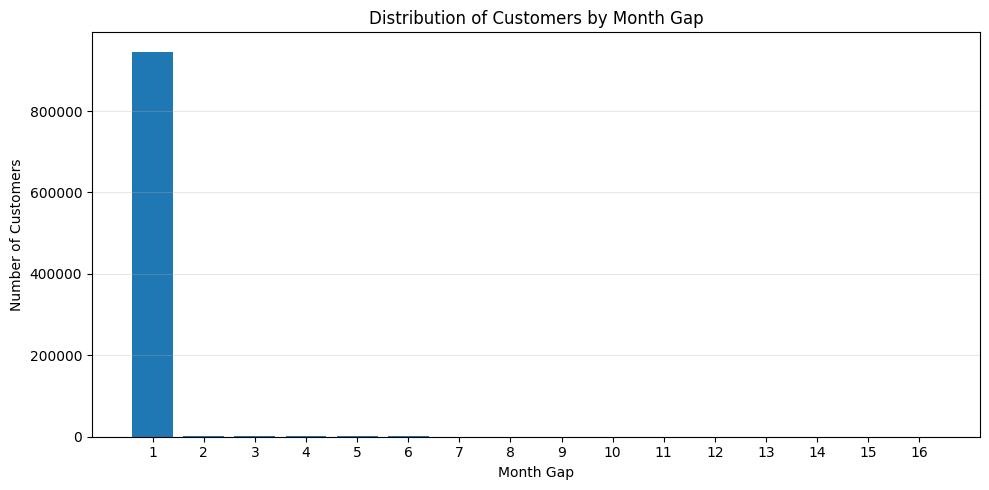

In [44]:
month_gap_distribution = q("""
    SELECT
        date_diff('month', previous_fecha_dato, fecha_dato) AS month_gap,
        COUNT(DISTINCT ncodpers) AS customers
    FROM target_eda_base
    WHERE previous_fecha_dato IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_gap_distribution["month_gap"], month_gap_distribution["customers"])
ax.set_xlabel("Month Gap")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Customers by Month Gap")
ax.set_xticks(month_gap_distribution["month_gap"])
ax.grid(axis="y", alpha=0.3)

save_and_show(fig, "month_gap_distribution.png")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,ownership_rate
0,ind_cco_fin_ult1,0.655484
1,ind_ctop_fin_ult1,0.129008
2,ind_recibo_ult1,0.127916
3,ind_ecue_fin_ult1,0.082744
4,ind_cno_fin_ult1,0.080867
5,ind_nom_pens_ult1,0.059359
6,ind_nomina_ult1,0.054660
7,ind_reca_fin_ult1,0.052536
8,ind_tjcr_fin_ult1,0.044389
9,ind_ctpp_fin_ult1,0.043306


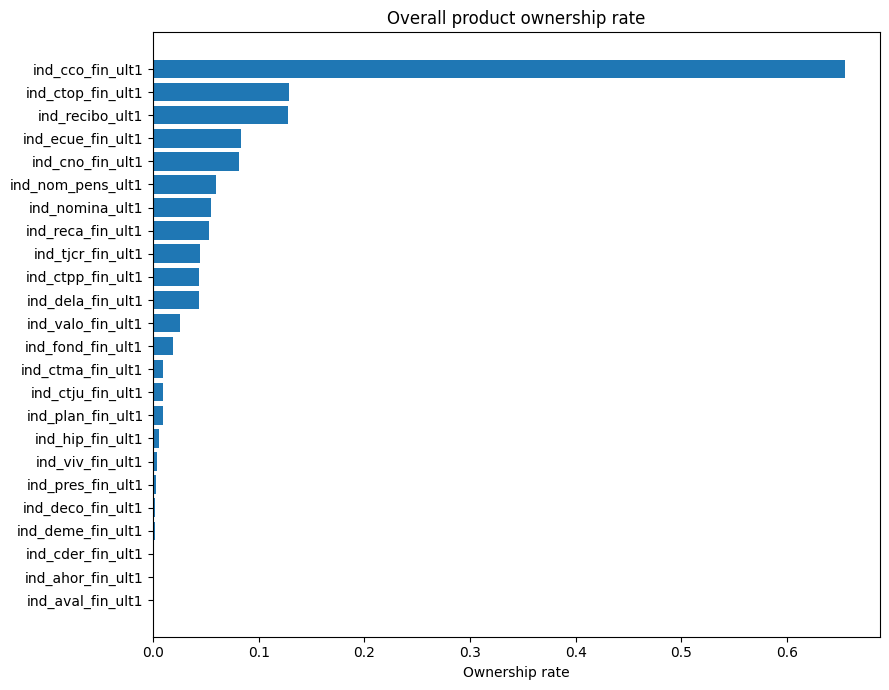

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

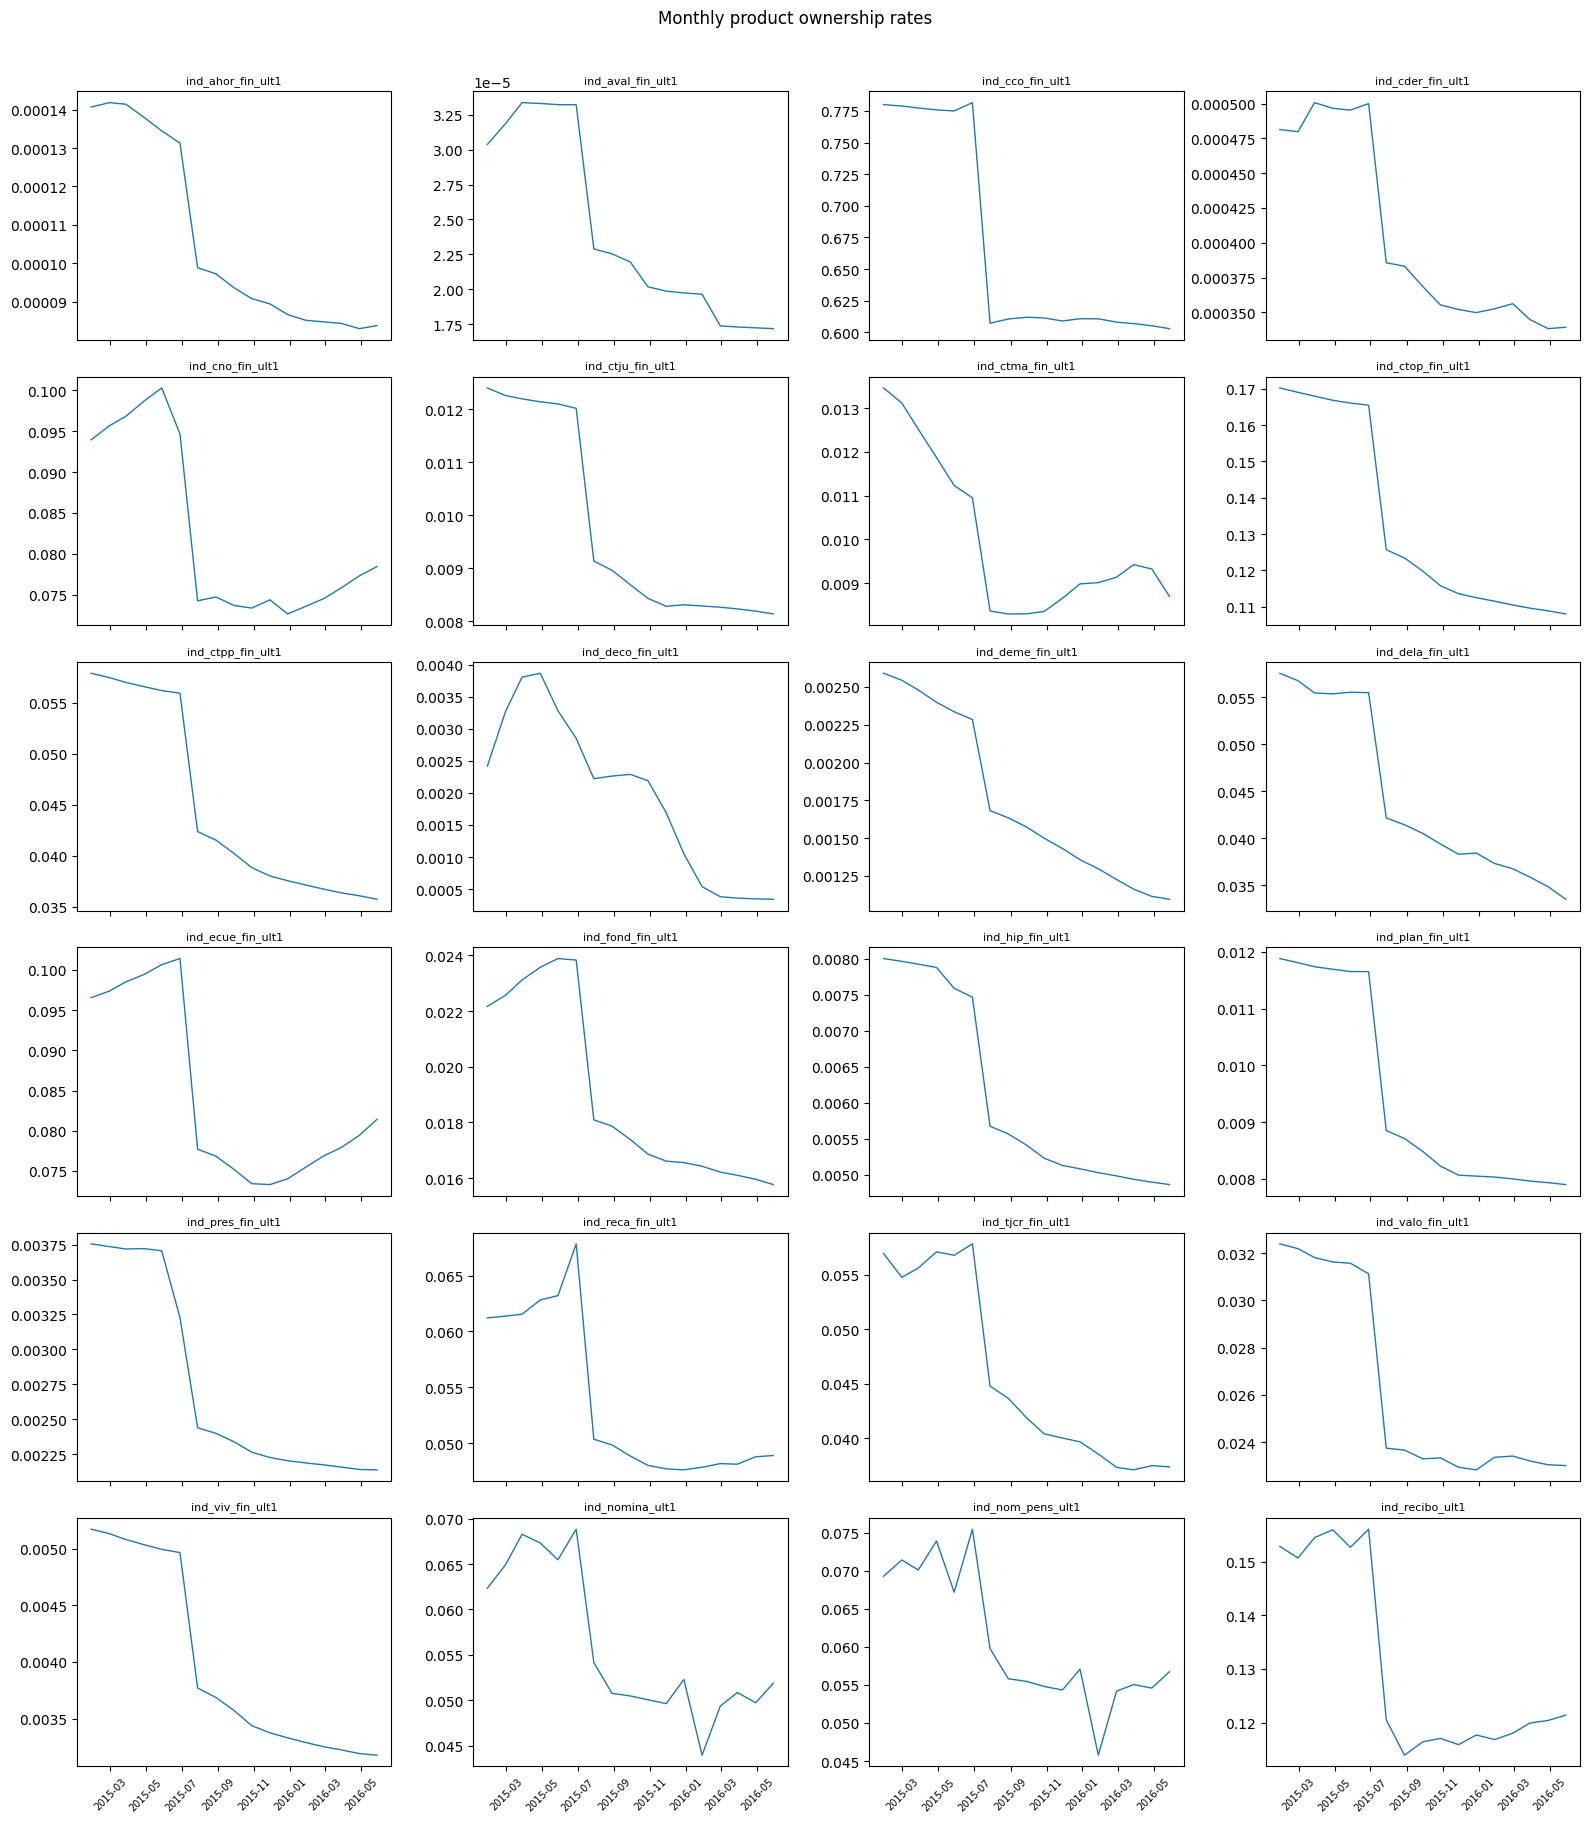

In [37]:
# 1-2. Ownership prevalence and monthly ownership trends reveal current-state imbalance and temporal changes.
ownership_source = f"(SELECT *, TRUE AS is_consecutive_month FROM read_parquet('{str(TRAIN_PARQUET).replace(chr(39), chr(39) * 2)}')) AS raw_ownership"
ownership_union = product_union('COALESCE({product}, 0)', source=ownership_source)
ownership_summary = q(f'SELECT product, AVG(value) AS ownership_rate FROM ({ownership_union}) GROUP BY 1 ORDER BY 2 DESC')
display(ownership_summary)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(ownership_summary['product'], ownership_summary['ownership_rate'])
ax.invert_yaxis(); ax.set_xlabel('Ownership rate'); ax.set_title('Overall product ownership rate')
save_and_show(fig, '01_overall_product_ownership.png')

monthly_ownership = q(f'''
    SELECT fecha_dato, product, AVG(value) AS ownership_rate
    FROM ({ownership_union}) GROUP BY 1, 2 ORDER BY 1, 2
''')
fig, axes = plt.subplots(6, 4, figsize=(16, 18), sharex=True)
for ax, product in zip(axes.flat, PRODUCT_COLUMNS):
    data = monthly_ownership[monthly_ownership['product'] == product]
    ax.plot(data.fecha_dato, data.ownership_rate, linewidth=1)
    ax.set_title(product, fontsize=8); ax.tick_params(axis='x', labelrotation=45, labelsize=7)
for ax in axes.flat[len(PRODUCT_COLUMNS):]: ax.set_visible(False)
fig.suptitle('Monthly product ownership rates', y=1.01)
save_and_show(fig, '02_monthly_product_ownership.png')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,acquisition_count,acquisition_rate
0,ind_recibo_ult1,153146,1.207545e-02
1,ind_nom_pens_ult1,84709,6.679245e-03
2,ind_nomina_ult1,73753,5.815372e-03
3,ind_tjcr_fin_ult1,69118,5.449906e-03
4,ind_cco_fin_ult1,69103,5.448723e-03
5,ind_cno_fin_ult1,37098,2.925151e-03
6,ind_ecue_fin_ult1,26361,2.078546e-03
7,ind_dela_fin_ult1,12659,9.981533e-04
8,ind_reca_fin_ult1,9234,7.280944e-04
9,ind_ctma_fin_ult1,6856,5.405908e-04


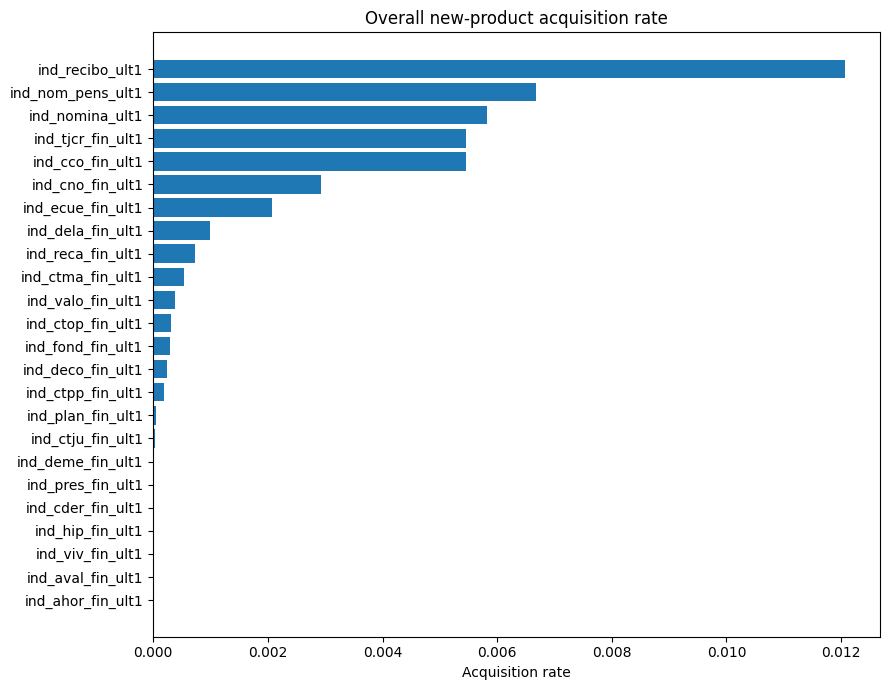

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,acquisition_bucket,customer_months,ratio
0,0 products,12235910,0.964793
1,1 product,355683,0.028045
2,2+ products,90828,0.007162


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

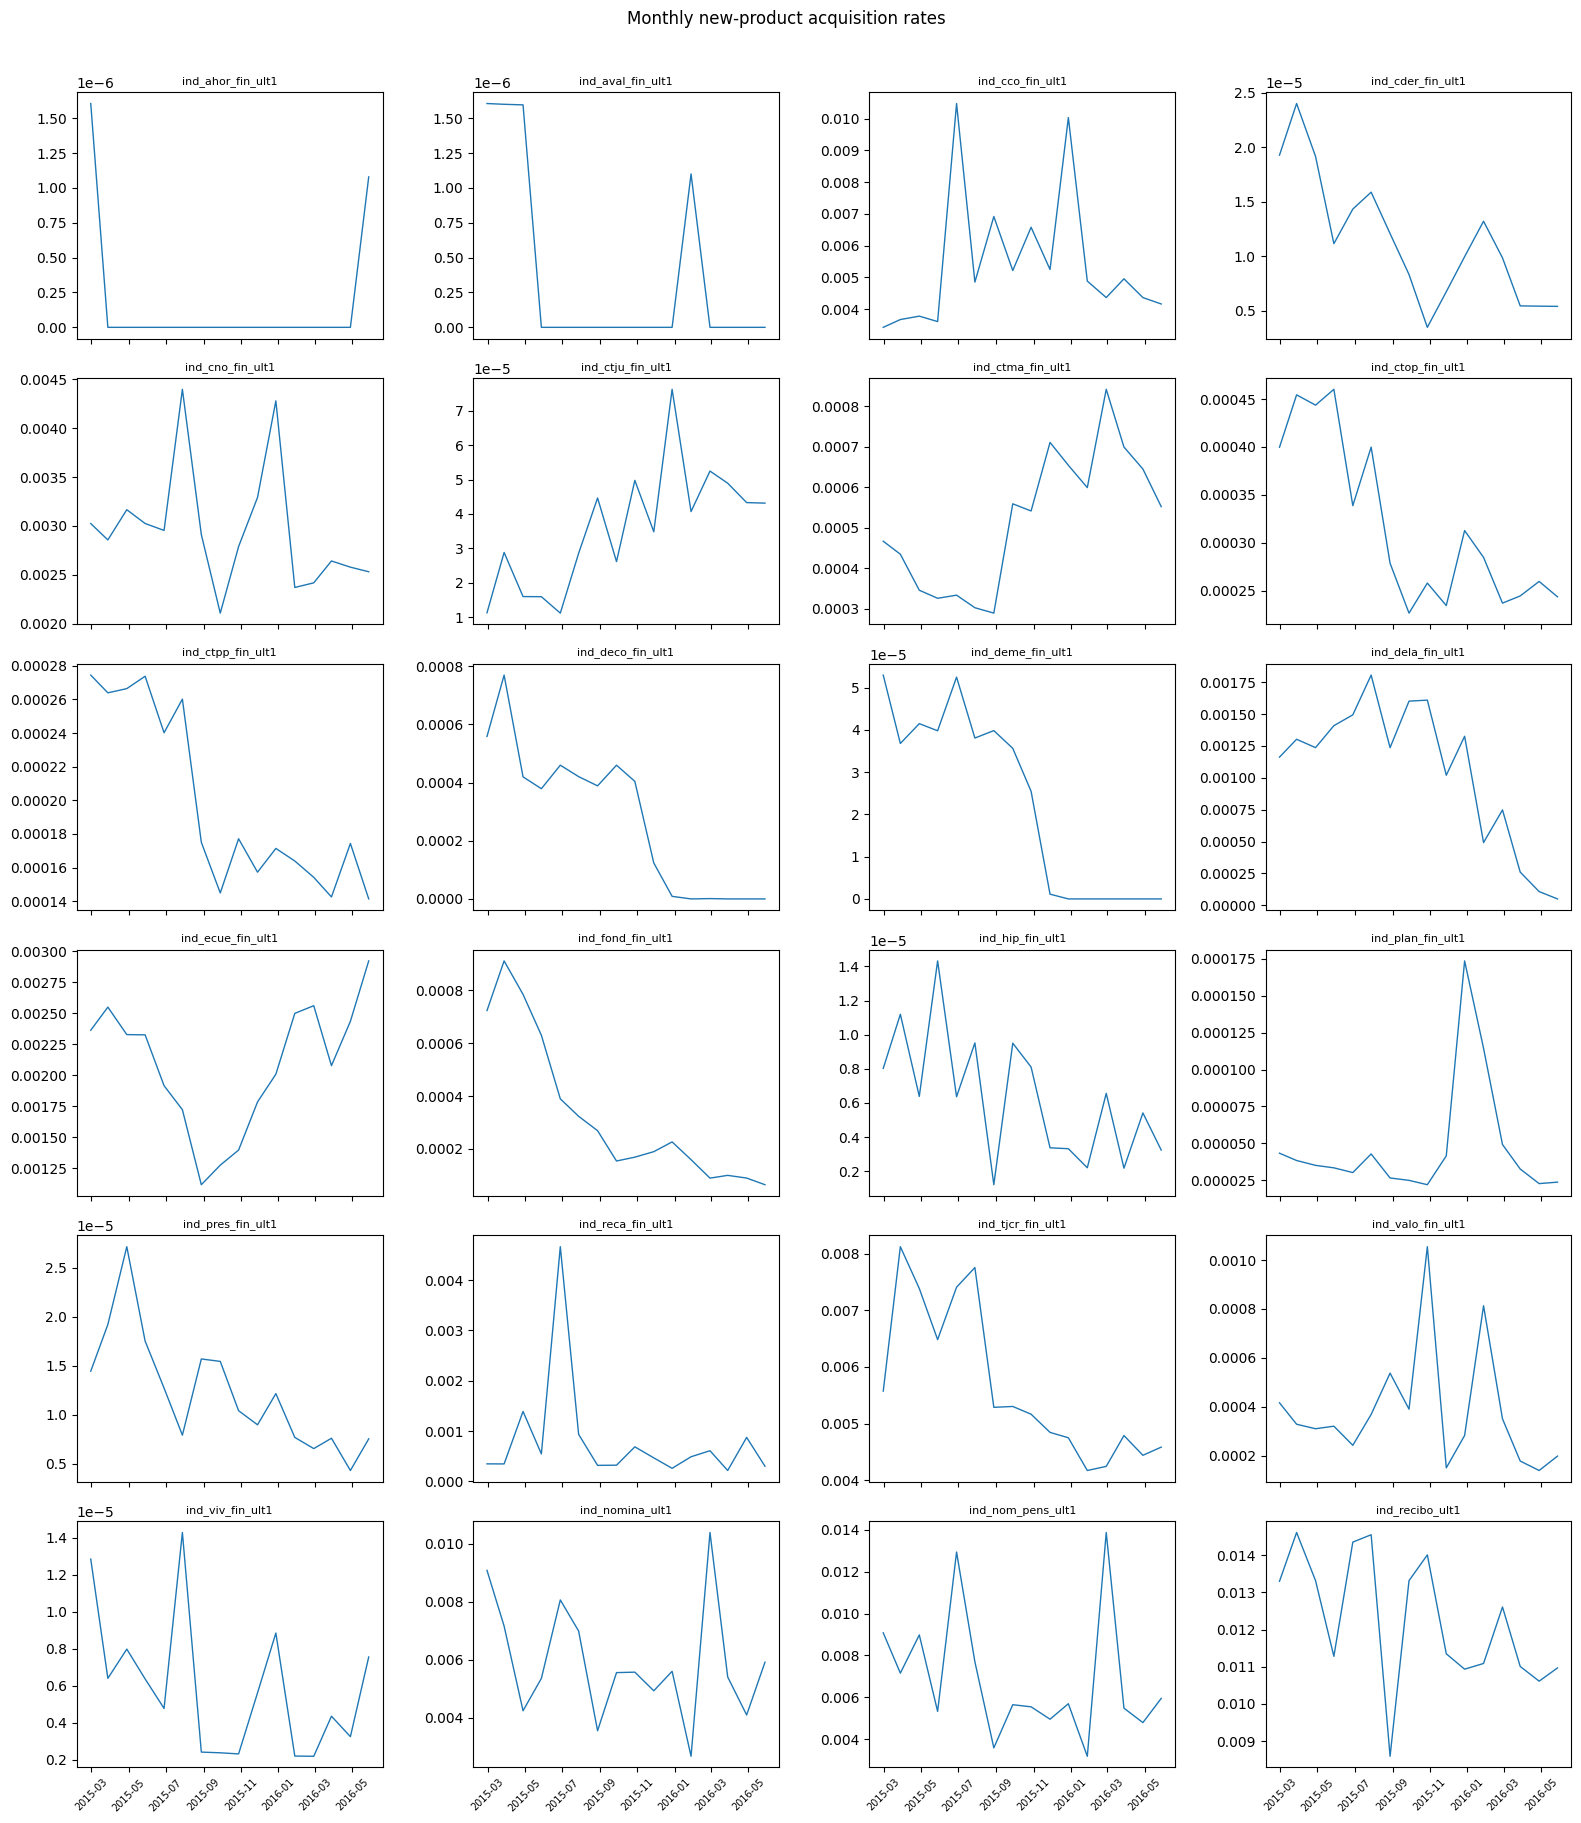

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fecha_dato,customer_months,customers_with_acquisition,total_new_products,acquisition_activity_rate,zero_rate,one_rate,two_plus_rate
0,2015-02-28,622926,23782,31372,0.038178,0.961822,0.028039,0.010139
1,2015-03-28,625094,25197,31948,0.040309,0.959691,0.031606,0.008703
2,2015-04-28,626698,25496,30427,0.040683,0.959317,0.034497,0.006186
3,2015-05-28,628135,21203,26311,0.033755,0.966245,0.027297,0.006459
4,2015-06-28,628603,33318,41745,0.053003,0.946997,0.042208,0.010795
5,2015-07-28,630249,26097,33362,0.041407,0.958593,0.032678,0.008730
6,2015-08-28,828361,24326,29490,0.029366,0.970634,0.024766,0.004601
7,2015-09-28,841795,28479,35696,0.033831,0.966169,0.026871,0.006960
8,2015-10-28,863690,32208,39803,0.037291,0.962709,0.030418,0.006873
9,2015-11-28,890170,28036,35215,0.031495,0.968505,0.025388,0.006107


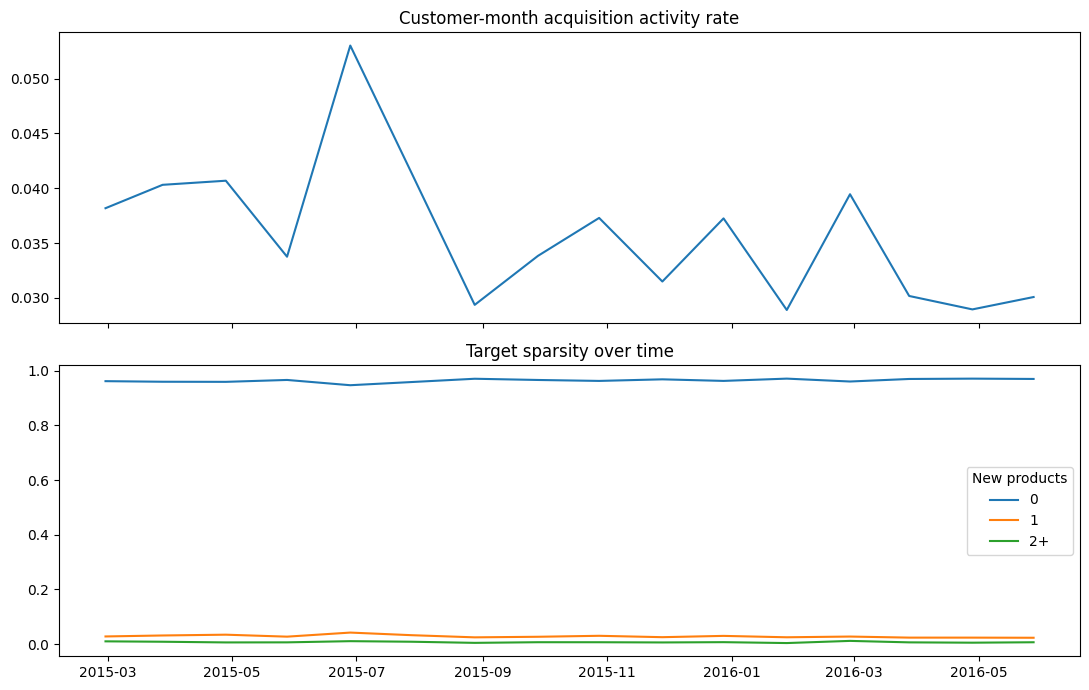

,fecha_dato,mean_absolute_rate_shift
0,2015-02-28,NaN
1,2015-03-28,0.000379
2,2015-04-28,0.000382
3,2015-05-28,0.000388
4,2015-06-28,0.001103
5,2015-07-28,0.000774
6,2015-08-28,0.000911
7,2015-09-28,0.000523
8,2015-10-28,0.000181
9,2015-11-28,0.000364


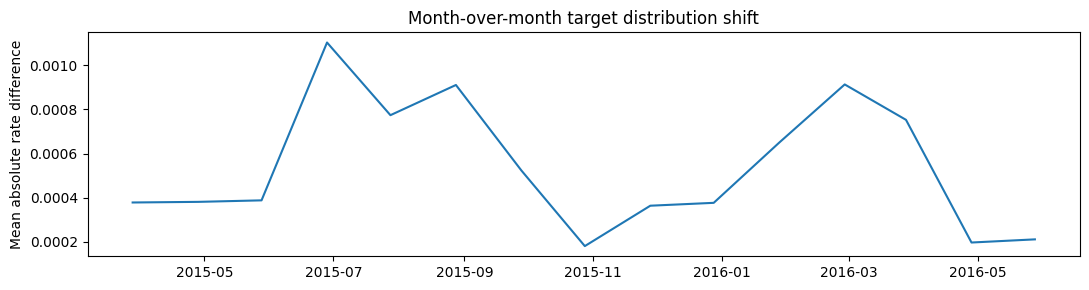

In [40]:
# 3-8. Acquisition summaries measure the actual recommendation target, its sparsity, temporal drift, and month-over-month shifts.
acquisition_union = product_union('acq_{raw_product}')
acquisition_summary = q(f'''
    SELECT product, SUM(value)::BIGINT AS acquisition_count, AVG(value) AS acquisition_rate
    FROM ({acquisition_union}) WHERE is_consecutive_month GROUP BY 1 ORDER BY acquisition_rate DESC
''')
display(acquisition_summary)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(acquisition_summary['product'], acquisition_summary['acquisition_rate'])
ax.invert_yaxis(); ax.set_xlabel('Acquisition rate'); ax.set_title('Overall new-product acquisition rate')
save_and_show(fig, '03_overall_product_acquisition.png')

acquisition_total_expression = ' + '.join(f'acq_{product}' for product in PRODUCT_COLUMNS)
sparsity = q(f'''
    SELECT CASE WHEN new_products = 0 THEN '0 products' WHEN new_products = 1 THEN '1 product' ELSE '2+ products' END AS acquisition_bucket,
           COUNT(*) AS customer_months, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS ratio
    FROM (SELECT {acquisition_total_expression} AS new_products FROM target_eda_base WHERE is_consecutive_month)
    GROUP BY 1 ORDER BY 1
''')
display(sparsity)

monthly_acquisition = q(f'''
    SELECT fecha_dato, product, AVG(value) AS acquisition_rate
    FROM ({acquisition_union}) WHERE is_consecutive_month GROUP BY 1, 2 ORDER BY 1, 2
''')
fig, axes = plt.subplots(6, 4, figsize=(16, 18), sharex=True)
for ax, product in zip(axes.flat, PRODUCT_COLUMNS):
    data = monthly_acquisition[monthly_acquisition['product'] == product]
    ax.plot(data.fecha_dato, data.acquisition_rate, linewidth=1)
    ax.set_title(product, fontsize=8); ax.tick_params(axis='x', labelrotation=45, labelsize=7)
fig.suptitle('Monthly new-product acquisition rates', y=1.01)
save_and_show(fig, '04_monthly_product_acquisition.png')

activity = q(f'''
    SELECT fecha_dato, COUNT(*) AS customer_months, SUM(new_products > 0)::BIGINT AS customers_with_acquisition,
           SUM(new_products)::BIGINT AS total_new_products, AVG((new_products > 0)::INTEGER) AS acquisition_activity_rate,
           AVG((new_products = 0)::INTEGER) AS zero_rate, AVG((new_products = 1)::INTEGER) AS one_rate, AVG((new_products >= 2)::INTEGER) AS two_plus_rate
    FROM (SELECT fecha_dato, {acquisition_total_expression} AS new_products FROM target_eda_base WHERE is_consecutive_month)
    GROUP BY 1 ORDER BY 1
''')
display(activity)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(activity.fecha_dato, activity.acquisition_activity_rate); axes[0].set_title('Customer-month acquisition activity rate')
axes[1].plot(activity.fecha_dato, activity.zero_rate, label='0'); axes[1].plot(activity.fecha_dato, activity.one_rate, label='1'); axes[1].plot(activity.fecha_dato, activity.two_plus_rate, label='2+')
axes[1].legend(title='New products'); axes[1].set_title('Target sparsity over time')
save_and_show(fig, '05_acquisition_activity_and_sparsity_over_time.png')

monthly_vector = monthly_acquisition.pivot(index='fecha_dato', columns='product', values='acquisition_rate').reindex(columns=PRODUCT_COLUMNS).sort_index()
target_shift = monthly_vector.diff().abs().mean(axis=1).rename('mean_absolute_rate_shift').reset_index()
display(target_shift)
fig, ax = plt.subplots(figsize=(11, 3)); ax.plot(target_shift.fecha_dato, target_shift.mean_absolute_rate_shift)
ax.set_title('Month-over-month target distribution shift'); ax.set_ylabel('Mean absolute rate difference')
save_and_show(fig, '06_target_distribution_shift.png')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

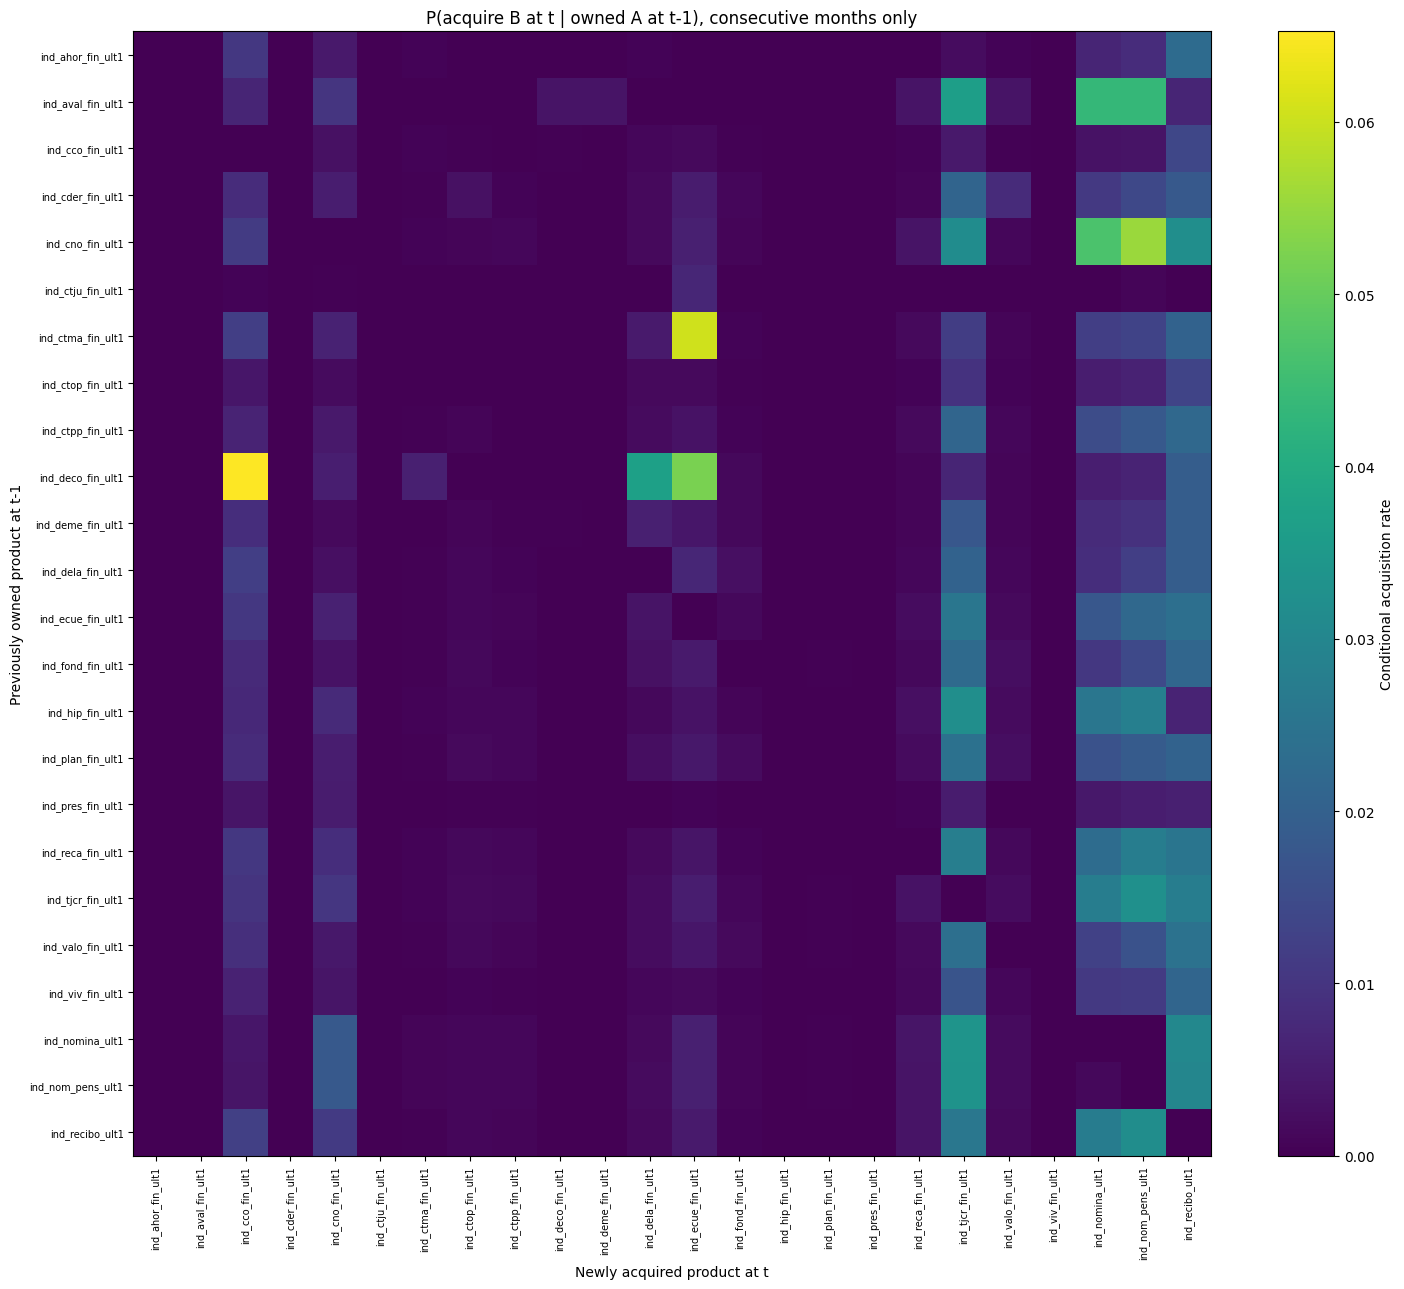

,product,ownership_rate,acquisition_count,acquisition_rate
2,ind_recibo_ult1,0.127916,153146,1.207545e-02
5,ind_nom_pens_ult1,0.059359,84709,6.679245e-03
6,ind_nomina_ult1,0.054660,73753,5.815372e-03
8,ind_tjcr_fin_ult1,0.044389,69118,5.449906e-03
0,ind_cco_fin_ult1,0.655484,69103,5.448723e-03
4,ind_cno_fin_ult1,0.080867,37098,2.925151e-03
3,ind_ecue_fin_ult1,0.082744,26361,2.078546e-03
10,ind_dela_fin_ult1,0.042967,12659,9.981533e-04
7,ind_reca_fin_ult1,0.052536,9234,7.280944e-04
13,ind_ctma_fin_ult1,0.009727,6856,5.405908e-04


In [39]:
# 9. Previous-ownership -> acquisition matrix finds candidate lag interactions without materialising panel rows in pandas.
matrix_aliases = []
matrix_expressions = []
for row_index, owned_product in enumerate(PRODUCT_COLUMNS):
    for column_index, acquired_product in enumerate(PRODUCT_COLUMNS):
        alias = f'm_{row_index}_{column_index}'
        matrix_aliases.append((owned_product, acquired_product, alias))
        matrix_expressions.append(f'AVG(CASE WHEN COALESCE(prev_{owned_product}, 0) = 1 THEN acq_{acquired_product} END) AS {alias}')
matrix_wide = q(f"SELECT {', '.join(matrix_expressions)} FROM target_eda_base WHERE is_consecutive_month")
transition_matrix = pd.DataFrame(
    [[matrix_wide.loc[0, f'm_{i}_{j}'] for j in range(len(PRODUCT_COLUMNS))] for i in range(len(PRODUCT_COLUMNS))],
    index=PRODUCT_COLUMNS, columns=PRODUCT_COLUMNS,
)
fig, ax = plt.subplots(figsize=(15, 13))
image = ax.imshow(transition_matrix.to_numpy(dtype=float), aspect='auto', interpolation='nearest')
ax.set_xticks(range(len(PRODUCT_COLUMNS)), PRODUCT_COLUMNS, rotation=90, fontsize=7)
ax.set_yticks(range(len(PRODUCT_COLUMNS)), PRODUCT_COLUMNS, fontsize=7)
ax.set_xlabel('Newly acquired product at t'); ax.set_ylabel('Previously owned product at t-1')
ax.set_title('P(acquire B at t | owned A at t-1), consecutive months only')
fig.colorbar(image, ax=ax, label='Conditional acquisition rate')
save_and_show(fig, '07_previous_ownership_to_acquisition_heatmap.png')

# 10. Final table combines the prevalence and true target frequency needed to identify rare/high-frequency products.
target_summary = ownership_summary.merge(acquisition_summary, on='product', how='inner').sort_values('acquisition_rate', ascending=False)
display(target_summary)
target_summary.to_csv(TARGET_EDA_DIR / 'target_summary_by_product.csv', index=False)
